## **Acoustic Environment Classifier for ESP32**

### **1. System Description**
This project consists of an **Edge AI** pipeline designed to run on an ESP32 microcontroller. It utilizes a **Long Short-Term Memory (LSTM)** recurrent neural network to analyze real-time audio and classify a room's environment, optimizing power and memory consumption through conversion to **TensorFlow Lite Micro**.

### **2. Classes and Descriptions**
*   **DEEP_FOCUS (Class 0):** Concentration or workshop mode. Identifies constant, flat sounds such as laptop typing, fans, and low-level murmurs.
*   **HIGH_ENGAGEMENT (Class 1):** Talk or keynote mode. Detects a dominant speaker interleaved with high-energy events such as applause and laughter.
*   **ROOM_EMPTY (Class 2):** Empty or break mode. Recognizes ambient silence, natural white noise (wind, light rain), and the absence of human activity.

### **3. Technical Process**
1.  **Collection and Augmentation:** A dataset was consolidated using professional sources (ESC-50) and tripled via noise injection and temporal shifts.
2.  **Feature Extraction (Hardware-Ready):** Audio is processed in windows of 1248 samples at 16kHz, normalized to **INT8** to exactly replicate the behavior of ESP32 analog-to-digital converters.
3.  **Model Architecture:** A two-layer LSTM with `unroll=True` was implemented, allowing the model to run on the microcontroller without needing complex GPU kernels.
4.  **Quantization and Export:** The model was converted to **Full INT8** format using a representative dataset, reducing its size and allowing the generation of a C++ header file (`model_data.cc`) ready for Arduino/ESP-IDF.

### **4. Results Obtained**
*   **Accuracy:** The model reaches **~74-76%** on the validation set.
*   **Performance by Class:**
    *   Excellent detection of empty rooms (**90% Recall**).
    *   Reliable distinction of focused work environments.
*   **Final Size:** The optimized model occupies approximately **320 KB**, fitting efficiently within the device's Flash memory.

## **Consolidated Data Acquisition & Preparation**

In [1]:
import os
import io
import librosa
import shutil
import soundfile as sf
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from datasets import load_dataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [2]:
MASTER_DIR = 'unified_esp32_dataset'
# Optimized sources for better stability and speech context
CLASSES = {
    '0': {'name': 'DEEP_FOCUS', 'sources': [("DynamicSuperbPrivate/EnvironmentalSoundClassification_ESC50-InteriorAndDomesticSounds_TTS", ['keyboard typing', 'mouse click'])]},
    '1': {'name': 'HIGH_ENGAGEMENT', 'sources': [
        ("DynamicSuperb/EnvironmentalSoundClassification_ESC50-HumanAndNonSpeechSounds", ['clapping', 'laughter']),
        ("ashraq/esc50", ['crowd', 'talking']) # High-quality conference/speech samples
    ]},
    '2': {'name': 'ROOM_EMPTY', 'sources': [
        ("ashraq/esc50", ['wind', 'rain', 'crackling_fire', 'crickets']) # Ambient/Background sounds for empty room context
    ]}
}

def setup_workspace():
    if os.path.exists(MASTER_DIR): shutil.rmtree(MASTER_DIR)
    for c_id in CLASSES: os.makedirs(os.path.join(MASTER_DIR, c_id), exist_ok=True)
    print(f"✓ Workspace ready at {MASTER_DIR}")

def augment_audio(data, sr):
    noise = np.random.randn(len(data)) * 0.003 # Slightly more noise for robustness
    data_noise = data + noise
    return [data_noise]

def fetch_and_save_data():
    for c_id, info in CLASSES.items():
        print(f"\nProcessing Class {c_id}: {info['name']}...")
        count = 0
        for dataset_path, labels in info['sources']:
            try:
                # Use 'train' split for ashraq/esc50 to get enough samples
                split_type = "train" if "esc50" in dataset_path else "test"
                ds = load_dataset(dataset_path, split=split_type)

                # Filtering logic for standard ESC-50 format vs others
                if "esc50" in dataset_path:
                    filtered_samples = [s for s in ds if s['category'] in labels]
                else:
                    filtered_samples = [ds[i] for i in range(min(len(ds), 100))]

                # Increase to 100 samples per source category as requested
                max_samples = 100
                for sample in filtered_samples[:max_samples]:
                    audio_data = sample['audio']['array']
                    sr = sample['audio']['sampling_rate']

                    # Normalize length for ESP32 input (1s window at 16kHz)
                    if len(audio_data) > 16000: audio_data = audio_data[:16000]

                    # Save original
                    sf.write(os.path.join(MASTER_DIR, c_id, f"{c_id}_{count}.wav"), audio_data, sr)
                    count += 1

                    # Save augmented
                    augmented_versions = augment_audio(audio_data, sr)
                    for aug_data in augmented_versions:
                        sf.write(os.path.join(MASTER_DIR, c_id, f"{c_id}_{count}.wav"), aug_data, sr)
                        count += 1
            except Exception as e:
                print(f"  [!] Skip or Error in {dataset_path}: {e}")
        print(f"  ✓ Total samples for {info['name']}: {count}")

setup_workspace()
fetch_and_save_data()

✓ Workspace ready at unified_esp32_dataset

Processing Class 0: DEEP_FOCUS...


README.md:   0%|          | 0.00/465 [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/80.2M [00:00<?, ?B/s]

Generating test split:   0%|          | 0/200 [00:00<?, ? examples/s]

  ✓ Total samples for DEEP_FOCUS: 200

Processing Class 1: HIGH_ENGAGEMENT...


...

data/train-00001-of-00002-27425e5c1846b4(…):   0%|          | 0.00/387M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/2000 [00:00<?, ? examples/s]

  ✓ Total samples for HIGH_ENGAGEMENT: 200

Processing Class 2: ROOM_EMPTY...


Repo card metadata block was not found. Setting CardData to empty.


  ✓ Total samples for ROOM_EMPTY: 200


## **Extract Features Raw**

In [3]:
DATASET_DIR = 'unified_esp32_dataset'
SR = 16000
SAMPLES = 1248

def extract_features_raw(file_path):
    """Extracts raw audio samples and reshapes them for the LSTM."""
    try:
        audio, sr = sf.read(file_path)

        # Convert to mono if stereo
        if len(audio.shape) > 1:
            audio = audio[:, 0]

        # Optional: Re-sampling logic if original sr differs from 16000Hz
        if sr != SR:
            pass

        # Truncate or pad with zeros to reach exactly 1248 samples
        if len(audio) < SAMPLES:
            audio = np.pad(audio, (0, SAMPLES - len(audio)), 'constant')
        else:
            audio = audio[:SAMPLES]

        # INT8 NORMALIZATION: Replicates the ESP32 "analogRead" behavior
        # Map floating audio (-1.0 to 1.0) to signed byte range [-128, 127]
        audio_max = np.max(np.abs(audio)) if np.max(np.abs(audio)) > 0 else 1
        audio_int8 = ((audio / audio_max) * 127).astype(np.int8)

        soft_audio = np.convolve(audio_int8, np.ones(3)/3, mode='same').astype(np.int8)

        # Reshape to the matrix expected by the LSTM (32 time steps, 39 features)
        features = soft_audio.reshape(32, 39)
        return features
    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        return None

# --- Load and Process Data ---
X, y = [], []

for label in sorted(os.listdir(DATASET_DIR)):
    path = os.path.join(DATASET_DIR, label)
    if os.path.isdir(path):
        print(f"Processing class {label} with Raw Audio...")
        for file in os.listdir(path):
            if file.endswith('.wav'):
                feat = extract_features_raw(os.path.join(path, file))
                if feat is not None:
                    X.append(feat)
                    y.append(int(label))

X = np.array(X)
y = np.array(y)
print(f"\n✓ Dataset synchronized with hardware! X={X.shape}, y={y.shape}")

Processing class 0 with Raw Audio...
Processing class 1 with Raw Audio...
Processing class 2 with Raw Audio...

✓ Dataset synchronized with hardware! X=(600, 32, 39), y=(600,)


## **Training Model using LSTM**

In [4]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Re-splitting to ensure proper stratification with larger dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

model = models.Sequential([
    layers.Input(batch_shape=(None, X_train.shape[1], X_train.shape[2])),
    layers.BatchNormalization(),
    layers.LSTM(32, return_sequences=True, unroll=True),
    layers.LSTM(16, unroll=True),
    layers.Dropout(0.45),
    layers.Dense(3, activation='softmax')
])

callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, min_lr=1e-6, verbose=1)
]

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Using batch_size=8 for better gradient stability than batch_size=1
history = model.fit(
    X_train, y_train,
    epochs=150,
    batch_size=8,
    validation_data=(X_test, y_test),
    callbacks=callbacks,
    verbose=1
)

print("\n[OPTIMIZATION] Model retrained with enhanced architecture.")

Epoch 1/150
60/60 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - accuracy: 0.3562 - loss: 1.1112 - val_accuracy: 0.3500 - val_loss: 1.1088 - learning_rate: 0.0010
Epoch 2/150
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.4208 - loss: 1.0670 - val_accuracy: 0.4167 - val_loss: 1.0928 - learning_rate: 0.0010
Epoch 3/150
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.4333 - loss: 1.0561 - val_accuracy: 0.4250 - val_loss: 1.0645 - learning_rate: 0.0010
Epoch 4/150
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.4292 - loss: 1.0364 - val_accuracy: 0.4000 - val_loss: 1.0730 - learning_rate: 0.0010
Epoch 5/150
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.4833 - loss: 1.0164 - val_accuracy: 0.4417 - val_loss: 1.0750 - learning_rate: 0.0010
Epoch 6/150
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.4917 - loss: 0.9912 - val_accuracy: 0.4500 - val_loss: 1.0648 - learning_rate: 0.0010
Epoch 7/150
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5146 - loss: 0.9925 - val

## **Validation**

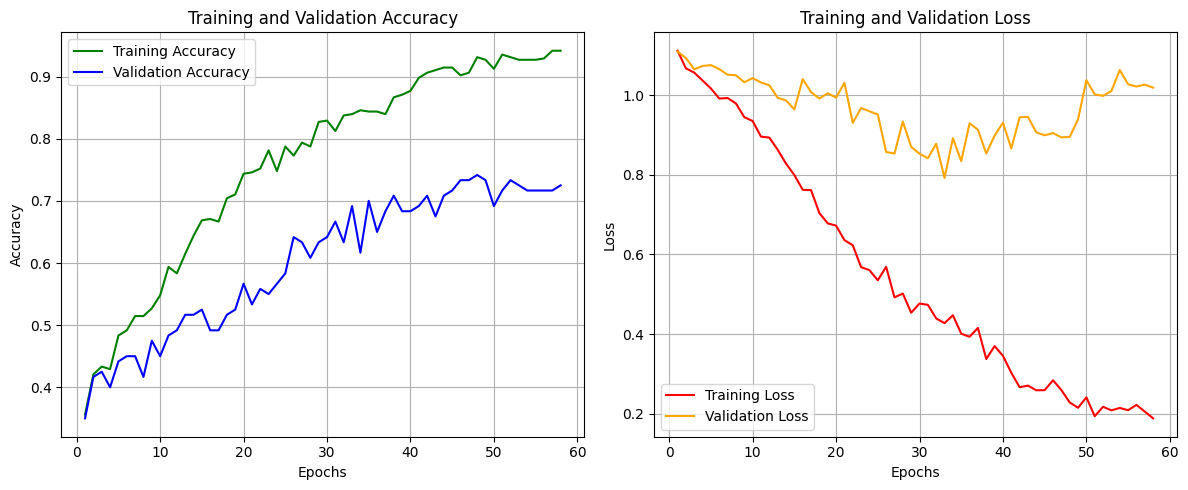

4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 290ms/step


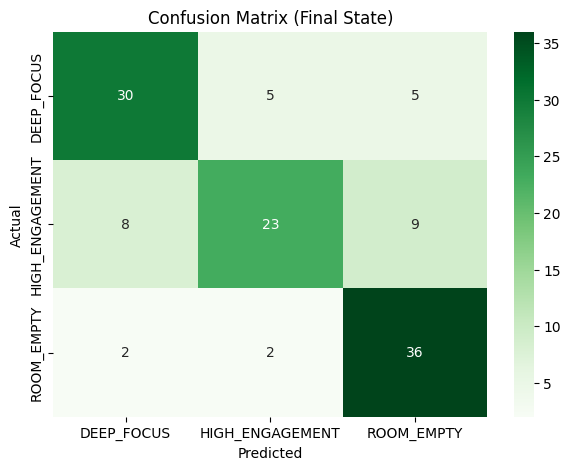


Classification Report:
                 precision    recall  f1-score   support

     DEEP_FOCUS       0.75      0.75      0.75        40
HIGH_ENGAGEMENT       0.77      0.57      0.66        40
     ROOM_EMPTY       0.72      0.90      0.80        40

       accuracy                           0.74       120
      macro avg       0.75      0.74      0.74       120
   weighted avg       0.75      0.74      0.74       120



In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

def plot_training_history(history):
    """Generates graphs for accuracy and loss over epochs."""
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(12, 5))

    # Plot Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, 'g', label='Training Accuracy')
    plt.plot(epochs, val_acc, 'b', label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    # Plot Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, 'r', label='Training Loss')
    plt.plot(epochs, val_loss, 'orange', label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

def evaluate_model(model, X_test, y_test):
    y_pred_prob = model.predict(X_test)
    y_pred = np.argmax(y_pred_prob, axis=1)

    class_names = ['DEEP_FOCUS', 'HIGH_ENGAGEMENT', 'ROOM_EMPTY']

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix (Final State)')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=class_names))

# Execution
if 'history' in locals():
    plot_training_history(history)

if 'model' in locals():
    evaluate_model(model, X_test, y_test)

## **Quantization to INT8**

In [6]:
def representative_data_gen():
    for i in range(100):
        dato = X_train[i:i+1].astype('float32')
        yield [dato]

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_data_gen

converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

tflite_quant_model = converter.convert()

with open('micro_lstm_model.tflite', 'wb') as f:
    f.write(tflite_quant_model)

import os
print(f"Model Size: {os.path.getsize('micro_lstm_model.tflite') / 1024:.2f} KB")

Saved artifact at '/tmp/tmp2hyjf6x_'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 32, 39), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  134832751453072: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134832751453264: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134832751452688: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134832751452496: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134832753144848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134832751452112: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134832751454992: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134832751455184: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134832751454416: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134832751455568: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134832751454800: Te

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


Model Size: 320.43 KB


## **Export Model**

In [7]:
!apt-get install -y xxd
!xxd -i micro_lstm_model.tflite > model_data.cc
!sed -i 's/unsigned char/const unsigned char/g' model_data.cc
!sed -i 's/model_quant_tflite/g_model/g' model_data.cc

print("Process complete. Download 'model_data.cc' from the file panel.")

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
xxd is already the newest version (2:8.2.3995-1ubuntu2.29).
xxd set to manually installed.
0 upgraded, 0 newly installed, 0 to remove and 1 not upgraded.
Process complete. Download 'model_data.cc' from the file panel.
